#SmartCart — Part 1: Data Preprocessing

## 0 — Imports

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

## 1.1 — Load Data

In [3]:
# Load raw datasets
user_data    = pd.read_csv('ecommerce_user_data.csv')
product_data = pd.read_csv('product_details.csv')

print(f"user_data    : {user_data.shape[0]:,} rows × {user_data.shape[1]} columns")
print(f"product_data : {product_data.shape[0]:,} rows × {product_data.shape[1]} columns")

user_data.head()

user_data    : 724 rows × 5 columns
product_data : 100 rows × 3 columns


,UserID,ProductID,Rating,Timestamp,Category
0,U000,P0009,5,2024-09-08,Books
1,U000,P0020,1,2024-09-02,Home
2,U000,P0012,4,2024-10-18,Books
3,U000,P0013,1,2024-09-18,Clothing
4,U000,P0070,4,2024-09-16,Toys


In [4]:
product_data.head()

,ProductID,ProductName,Category
0,P0000,Toys Item 0,Clothing
1,P0001,Clothing Item 1,Electronics
2,P0002,Books Item 2,Electronics
3,P0003,Clothing Item 3,Electronics
4,P0004,Clothing Item 4,Electronics


## 1.2 — Data Cleaning & Quality Check

In [5]:
# Data types & null check
print("=== user_data dtypes & nulls ===")
print(user_data.dtypes)
print("\nMissing values:")
print(user_data.isnull().sum())

# Convert Timestamp to datetime
user_data['Timestamp'] = pd.to_datetime(user_data['Timestamp'])

# Remove duplicate interactions (same UserID + ProductID pair)
before = len(user_data)
user_data = user_data.drop_duplicates(subset=['UserID', 'ProductID'], keep='last')
print(f"\nDuplicate rows removed : {before - len(user_data)}")
print(f"Clean dataset size     : {user_data.shape}")

=== user_data dtypes & nulls ===
UserID       object
ProductID    object
Rating        int64
Timestamp    object
Category     object
dtype: object

Missing values:
UserID       0
ProductID    0
Rating       0
Timestamp    0
Category     0
dtype: int64

Duplicate rows removed : 0
Clean dataset size     : (724, 5)


In [6]:
# Basic statistics
print(f"Unique users    : {user_data['UserID'].nunique()}")
print(f"Unique products : {user_data['ProductID'].nunique()}")
print(f"Categories      : {sorted(user_data['Category'].unique())}")
print(f"Rating range    : {user_data['Rating'].min()} – {user_data['Rating'].max()}")
print(f"\nRating distribution:")
print(user_data['Rating'].value_counts().sort_index())

Unique users    : 50
Unique products : 100
Categories      : ['Beauty', 'Books', 'Clothing', 'Electronics', 'Home', 'Toys']
Rating range    : 1 – 5

Rating distribution:
Rating
1    170
2    129
3    147
4    134
5    144
Name: count, dtype: int64


## 1.3 — Merge User Data with Product Metadata

We join on `ProductID` to enrich each interaction row with the product's `ProductName`.

In [7]:
# Rename product_data's Category to avoid collision (user_data already has Category)
product_data_renamed = product_data.rename(columns={'Category': 'ProductCategory'})

merged_data = user_data.merge(product_data_renamed[['ProductID', 'ProductName']],
                               on='ProductID', how='left')

print(f"Merged dataset shape: {merged_data.shape}")
print(f"Unmatched products  : {merged_data['ProductName'].isnull().sum()}")
merged_data.head()

Merged dataset shape: (724, 6)
Unmatched products  : 0


,UserID,ProductID,Rating,Timestamp,Category,ProductName
0,U000,P0009,5,2024-09-08,Books,Clothing Item 9
1,U000,P0020,1,2024-09-02,Home,Clothing Item 20
2,U000,P0012,4,2024-10-18,Books,Beauty Item 12
3,U000,P0013,1,2024-09-18,Clothing,Clothing Item 13
4,U000,P0070,4,2024-09-16,Toys,Beauty Item 70


## 1.4 — User–Item Matrix

A matrix where rows = users, columns = products, and values = ratings.  
Missing entries (user never interacted with that product) are filled with **0**.

In [8]:
# Build the user–item matrix
user_item_matrix = user_data.pivot_table(
    index='UserID',
    columns='ProductID',
    values='Rating'
)

# Fill NaN (no interaction) with 0
user_item_matrix_filled = user_item_matrix.fillna(0)

print(f"Matrix shape : {user_item_matrix_filled.shape}  (users × products)")

# Sparsity = fraction of entries that are 0
n_total    = user_item_matrix_filled.shape[0] * user_item_matrix_filled.shape[1]
n_rated    = (user_item_matrix_filled != 0).sum().sum()
sparsity   = 1 - n_rated / n_total
print(f"Rated entries: {n_rated}  /  {n_total}  ({(1-sparsity)*100:.1f}% filled)")
print(f"Sparsity     : {sparsity*100:.1f}%")

user_item_matrix_filled.head()

Matrix shape : (50, 100)  (users × products)
Rated entries: 724  /  5000  (14.5% filled)
Sparsity     : 85.5%


ProductID,P0000,P0001,P0002,P0003,P0004,P0005,P0006,P0007,P0008,P0009,P0010,P0011,P0012,P0013,P0014,P0015,P0016,P0017,P0018,P0019,P0020,P0021,P0022,P0023,P0024,P0025,P0026,P0027,P0028,P0029,P0030,P0031,P0032,P0033,P0034,P0035,P0036,P0037,P0038,P0039,P0040,P0041,P0042,P0043,P0044,P0045,P0046,P0047,P0048,P0049,P0050,P0051,P0052,P0053,P0054,P0055,P0056,P0057,P0058,P0059,P0060,P0061,P0062,P0063,P0064,P0065,P0066,P0067,P0068,P0069,P0070,P0071,P0072,P0073,P0074,P0075,P0076,P0077,P0078,P0079,P0080,P0081,P0082,P0083,P0084,P0085,P0086,P0087,P0088,P0089,P0090,P0091,P0092,P0093,P0094,P0095,P0096,P0097,P0098,P0099
UserID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
U000,0.0,0.0,0.0,3.0,0.0,5.0,0.0,3.0,0.0,5.0,0.0,0.0,4.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,2.0,0.0,1.0,3.0,5.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
U001,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,1.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,2.0,4.0,0.0,0.0,4.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0
U002,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,1.0,0.0,5.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,4.0,0.0,4.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
U003,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
U004,0.0,3.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,3.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0,0.0,2.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,4.0,3.0


## 1.5 — Aggregate User Behaviour by Category


In [9]:
user_category_agg = (
    user_data
    .groupby(['UserID', 'Category'])
    .agg(TotalInteractions=('Rating', 'count'),
         AverageRating=('Rating', 'mean'))
    .reset_index()
)

# Round average for readability
user_category_agg['AverageRating'] = user_category_agg['AverageRating'].round(2)

print(f"Aggregation table shape: {user_category_agg.shape}")
user_category_agg.head(12)

Aggregation table shape: (272, 4)


,UserID,Category,TotalInteractions,AverageRating
0,U000,Books,6,3.67
1,U000,Clothing,3,1.67
2,U000,Electronics,3,3.67
3,U000,Home,2,1.00
4,U000,Toys,6,3.50
5,U001,Beauty,1,4.00
6,U001,Books,4,2.50
7,U001,Clothing,4,2.50
8,U001,Electronics,2,4.00
9,U001,Home,1,2.00


## 1.6 — Exploratory Visualisations

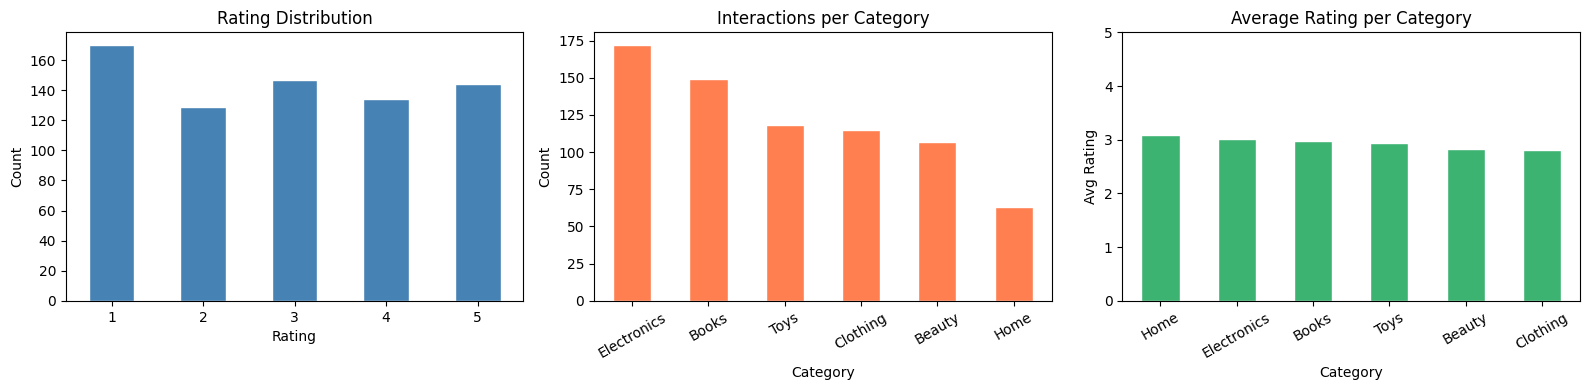

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

#(a) Rating distribution
user_data['Rating'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Rating Distribution')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

#(b) Interactions per category
user_data['Category'].value_counts().plot(
    kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Interactions per Category')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=30)

#(c) Average rating per category
avg_by_cat = user_data.groupby('Category')['Rating'].mean().sort_values(ascending=False)
avg_by_cat.plot(kind='bar', ax=axes[2], color='mediumseagreen', edgecolor='white')
axes[2].set_title('Average Rating per Category')
axes[2].set_xlabel('Category')
axes[2].set_ylabel('Avg Rating')
axes[2].set_ylim(0, 5)
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('part1_eda_plots.png', dpi=150)
plt.show()

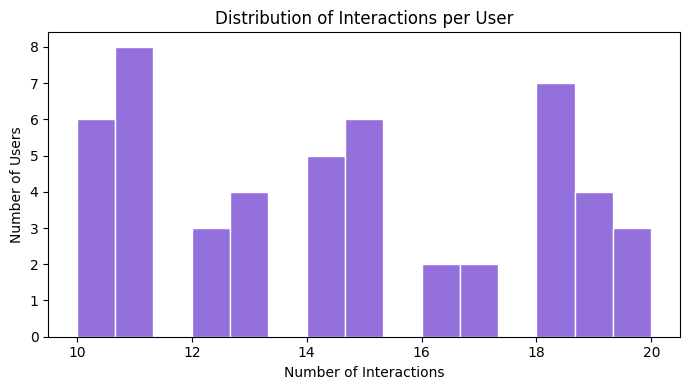

Min interactions per user : 10
Max interactions per user : 20
Mean interactions per user: 14.5


In [11]:
#Interactions-per-user histogram
interactions_per_user = user_data.groupby('UserID').size()

plt.figure(figsize=(7, 4))
plt.hist(interactions_per_user, bins=15, color='mediumpurple', edgecolor='white')
plt.title('Distribution of Interactions per User')
plt.xlabel('Number of Interactions')
plt.ylabel('Number of Users')
plt.tight_layout()
plt.savefig('part1_interactions_histogram.png', dpi=150)
plt.show()

print(f"Min interactions per user : {interactions_per_user.min()}")
print(f"Max interactions per user : {interactions_per_user.max()}")
print(f"Mean interactions per user: {interactions_per_user.mean():.1f}")

## 1.7 — Export Preprocessed Artefacts


In [12]:
# Save cleaned interaction data
user_data.to_csv('user_data_clean.csv', index=False)

# Save user–item matrix (filled)
user_item_matrix_filled.to_csv('user_item_matrix.csv')

# Save category aggregation
user_category_agg.to_csv('user_category_agg.csv', index=False)

print("Artefacts saved to outputs/")

Artefacts saved to outputs/


## Preprocessing Summary

| Step | Result |
|------|--------|
| Raw interactions | 724 rows |
| After deduplication | cleaned (duplicates removed) |
| Unique users | 50 |
| Unique products | 100 |
| Categories | Books, Beauty, Clothing, Electronics, Home, Toys |
| User–item matrix | 50 × 100 (≈ 85% sparse) |
| Outputs | `user_data_clean.csv`, `user_item_matrix.csv`, `user_category_agg.csv` |